In [12]:
# !pip uninstall -y numpy
# !pip install numpy==1.26.4

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfreqz

In [14]:
music_df = pd.read_csv('data/trial data/Aranza_with_music.csv')
music_df['timestamp'] = music_df['timestamp'] - music_df['timestamp'].iloc[0]
music_df.head()

,timestamp,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,0.000000,-6.134770,-10.974758,-3.290733,-8.490552,-6.190153,-3.192663,-9.070216,-3.696755,-11.653331,-4.778467,5.867876,5.443120,-3.571685,8.815484,-3.490360,7.578889
1,0.004038,-2.677999,-7.519231,-2.033387,-5.626390,-4.373363,-2.379029,-7.126967,-3.745207,-9.072701,-4.957644,4.730648,3.012866,-4.108777,9.058551,-5.384641,5.737974
2,0.008038,-1.270984,-5.437748,-1.600030,-3.781638,-2.647695,-1.579290,-6.062822,-3.822019,-6.557793,-5.435318,3.827914,0.532556,-4.552156,9.501005,-7.023007,4.441598
3,0.012029,-2.153540,-5.312373,-2.097561,-4.096406,-1.866991,-1.121506,-6.616709,-4.225417,-5.188830,-5.733292,4.173772,0.523376,-4.555222,10.110385,-6.163405,5.107235
4,0.016021,-3.209701,-5.405239,-3.012092,-5.876771,-2.136584,-0.964843,-7.847746,-5.508308,-4.647661,-4.836787,5.343925,2.097027,-4.718582,10.645931,-4.084081,6.877524


In [15]:
# array of channels, from 1 to 16
channels = np.array(['FP1', 'FP2', 'F7', 'F3', 'F4', 'F8', 'T3', 'C3', 'C4', 'T4', 'T5', 'P3', 'P4', 'T6', 'O1', 'O2'])
for i in range(len(channels)):
    print(f'Channel {i+1} is {channels[i]}')

Channel 1 is FP1
Channel 2 is FP2
Channel 3 is F7
Channel 4 is F3
Channel 5 is F4
Channel 6 is F8
Channel 7 is T3
Channel 8 is C3
Channel 9 is C4
Channel 10 is T4
Channel 11 is T5
Channel 12 is P3
Channel 13 is P4
Channel 14 is T6
Channel 15 is O1
Channel 16 is O2


In [ ]:
# rename channels to electrode placement

for i in range(len(channels)):
    music_df.rename(columns={f'ch{i+1}': channels[i]}, inplace=True)
    # center data by subtracting mean

    print(f'{channels[i]} mean: {music_df[f"{channels[i]}"].mean()}')
    music_df[f'{channels[i]}'] = music_df[f'{channels[i]}'] - music_df[f'{channels[i]}'].mean()

print(music_df.head())

FP1 mean: 0.0
FP2 mean: -1.523782031340771e-16
F7 mean: 1.2698183594506425e-16
F3 mean: -1.015854687560514e-16
F4 mean: -1.015854687560514e-16
F8 mean: -1.523782031340771e-16
T3 mean: 0.0
C3 mean: 1.7777457032308996e-16
C4 mean: 5.07927343780257e-17
T4 mean: -2.031709375121028e-16
T5 mean: -2.4380512501452336e-15
P3 mean: -6.349091797253212e-17
P4 mean: 2.031709375121028e-16
T6 mean: 2.031709375121028e-16
O1 mean: 4.063418750242056e-16
O2 mean: -2.031709375121028e-15
   timestamp       FP1        FP2        F7        F3        F4        F8  \
0   0.000000 -6.577850 -11.337475 -3.484268 -8.796904 -6.538639 -3.593031   
1   0.004038 -3.121079  -7.881947 -2.226921 -5.932742 -4.721849 -2.779397   
2   0.008038 -1.714064  -5.800464 -1.793564 -4.087990 -2.996180 -1.979657   
3   0.012029 -2.596620  -5.675089 -2.291095 -4.402759 -2.215476 -1.521873   
4   0.016021 -3.652781  -5.767955 -3.205626 -6.183123 -2.485070 -1.365210   

         T3        C3         C4        T4         T5        P3  

In [ ]:
# define filters
# buttterworth filter aims to attenuate frequencies we are not interested in,
# while preserving the frequencies we are intested in

def butter_bandpass(lowcut, highcut, fs, order):
    nyq = fs/2
    low = lowcut /nyq
    high = highcut/nyq
    sos = butter(order, [low,high], analog=False, btype='band', output='sos')
    return sos

def butter_bandpass_filter(data, lowcut, highcut, fs, order):
    sos = butter_bandpass(lowcut, highcut, fs, order=order)
    y = sosfiltfilt(sos, data)
    return y



In [ ]:
# filtering parameters
# from COGS 189 A1
fs = 500
lowcut = 0.1
highcut = 30

# lowcut_temp = 20
# highcut_temp = 40
# plt.figure(0)
# plt.clf()
# plt.plot([0, lowcut_temp], [0,0], 'b-')
# plt.plot([lowcut_temp, lowcut_temp], [0,1], 'b-')
# plt.plot([lowcut_temp, highcut_temp], [1,1], 'b-')
# plt.plot([highcut_temp, highcut_temp], [1,0], 'b-')
# plt.plot([highcut_temp, 100], [0,0], 'b-', label='ideal filter')
# plt.grid(True)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Gain')
# plt.legend(loc='best')
# plt.title('Ideal Bandpass Filter')
# plt.show()

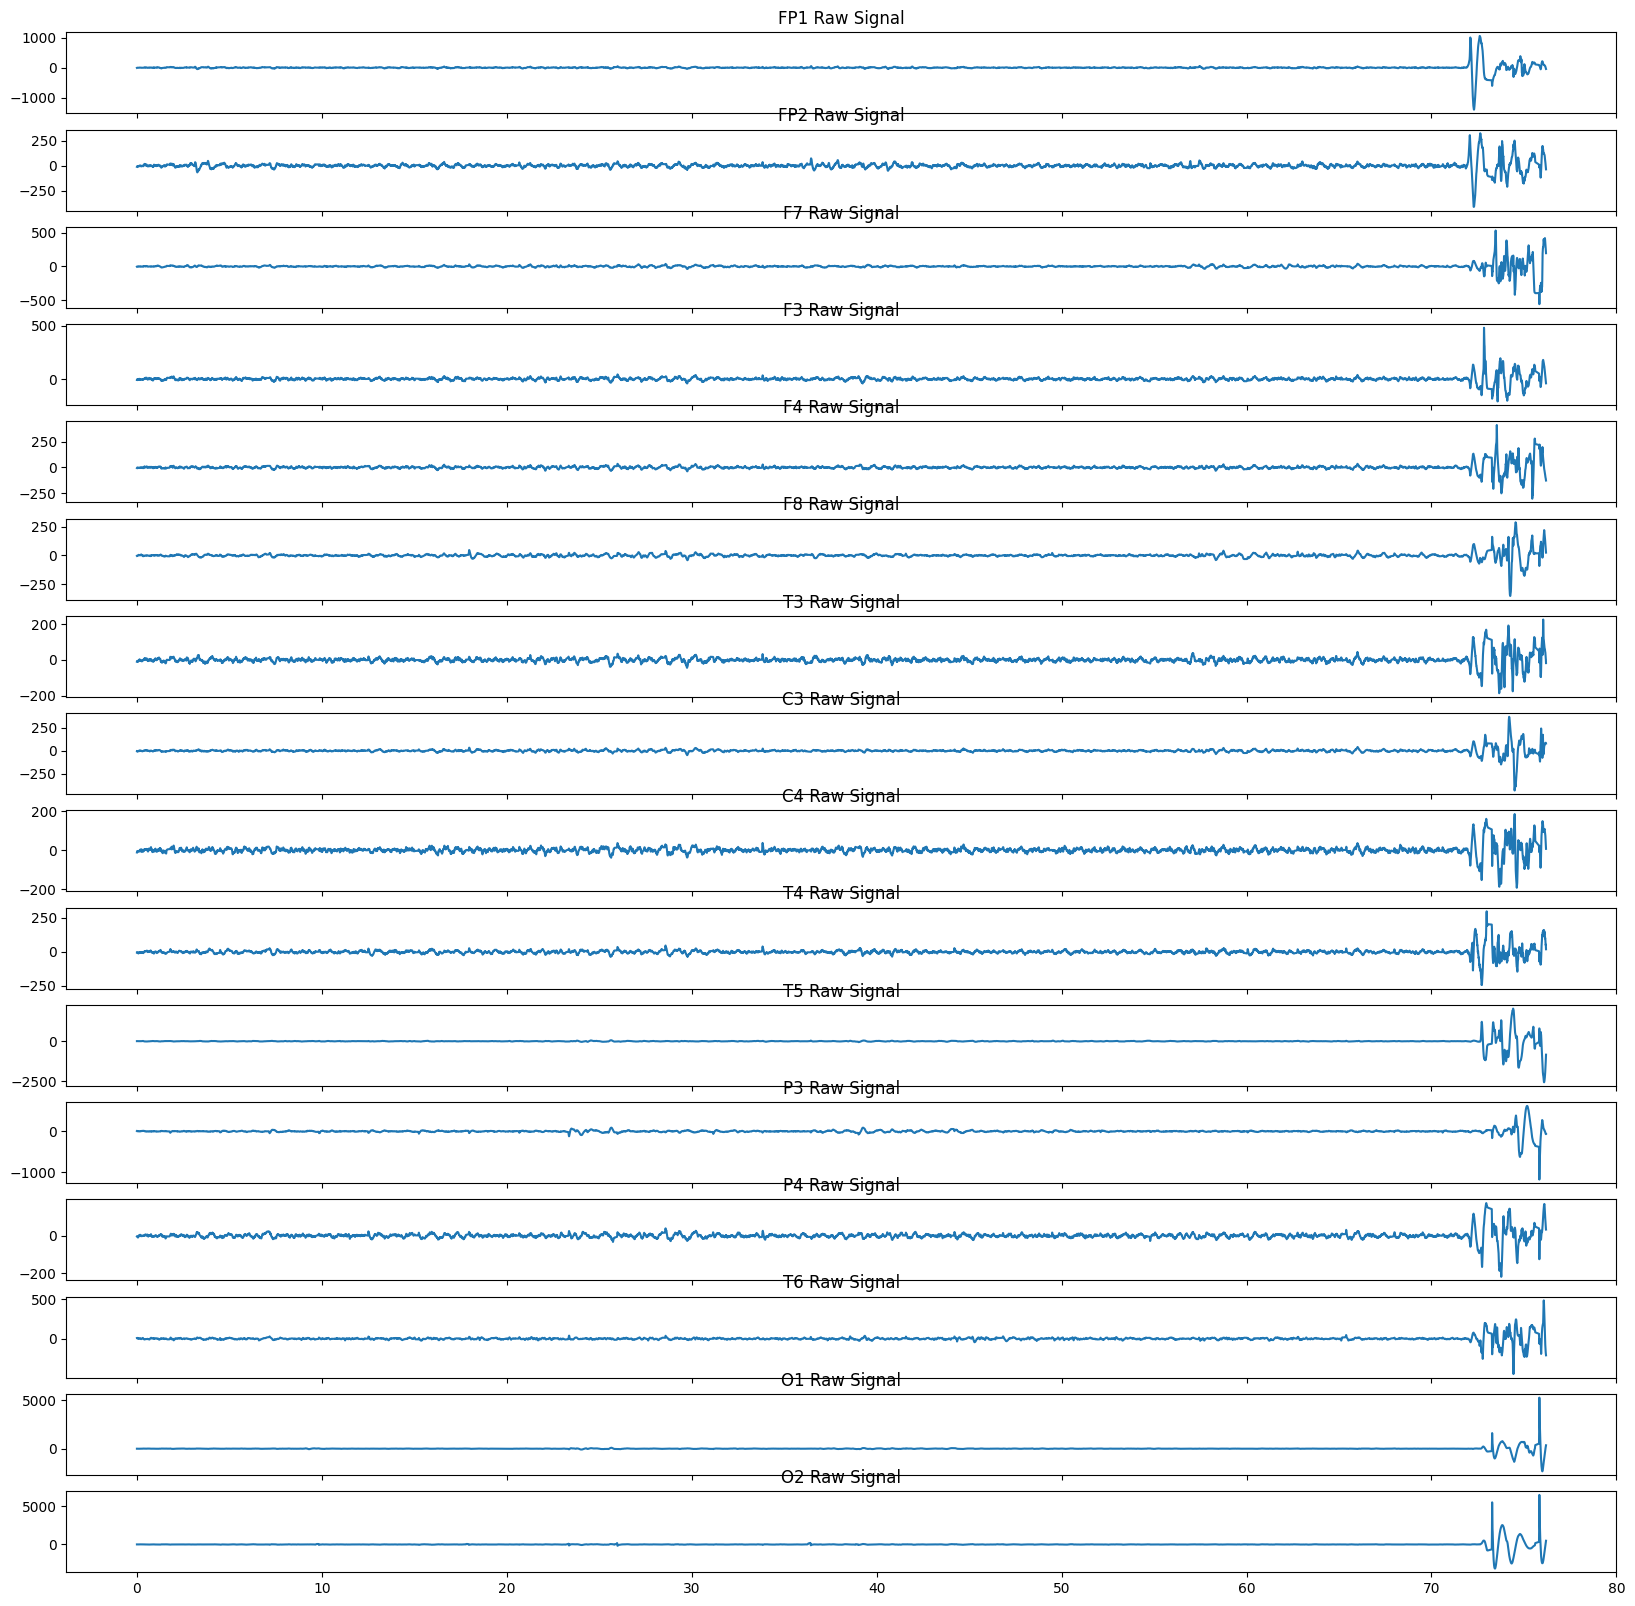

In [ ]:
# 17906 time stamps, 16 channels + timestamp
music_df.shape
fig, axes = plt.subplots(16,1, figsize=(20,20), sharex=True)
for i in range(len(channels)):
    axes[i].plot(music_df['timestamp'], music_df[f'{channels[i]}'])
    axes[i].set_title(f'{channels[i]} Raw Signal')

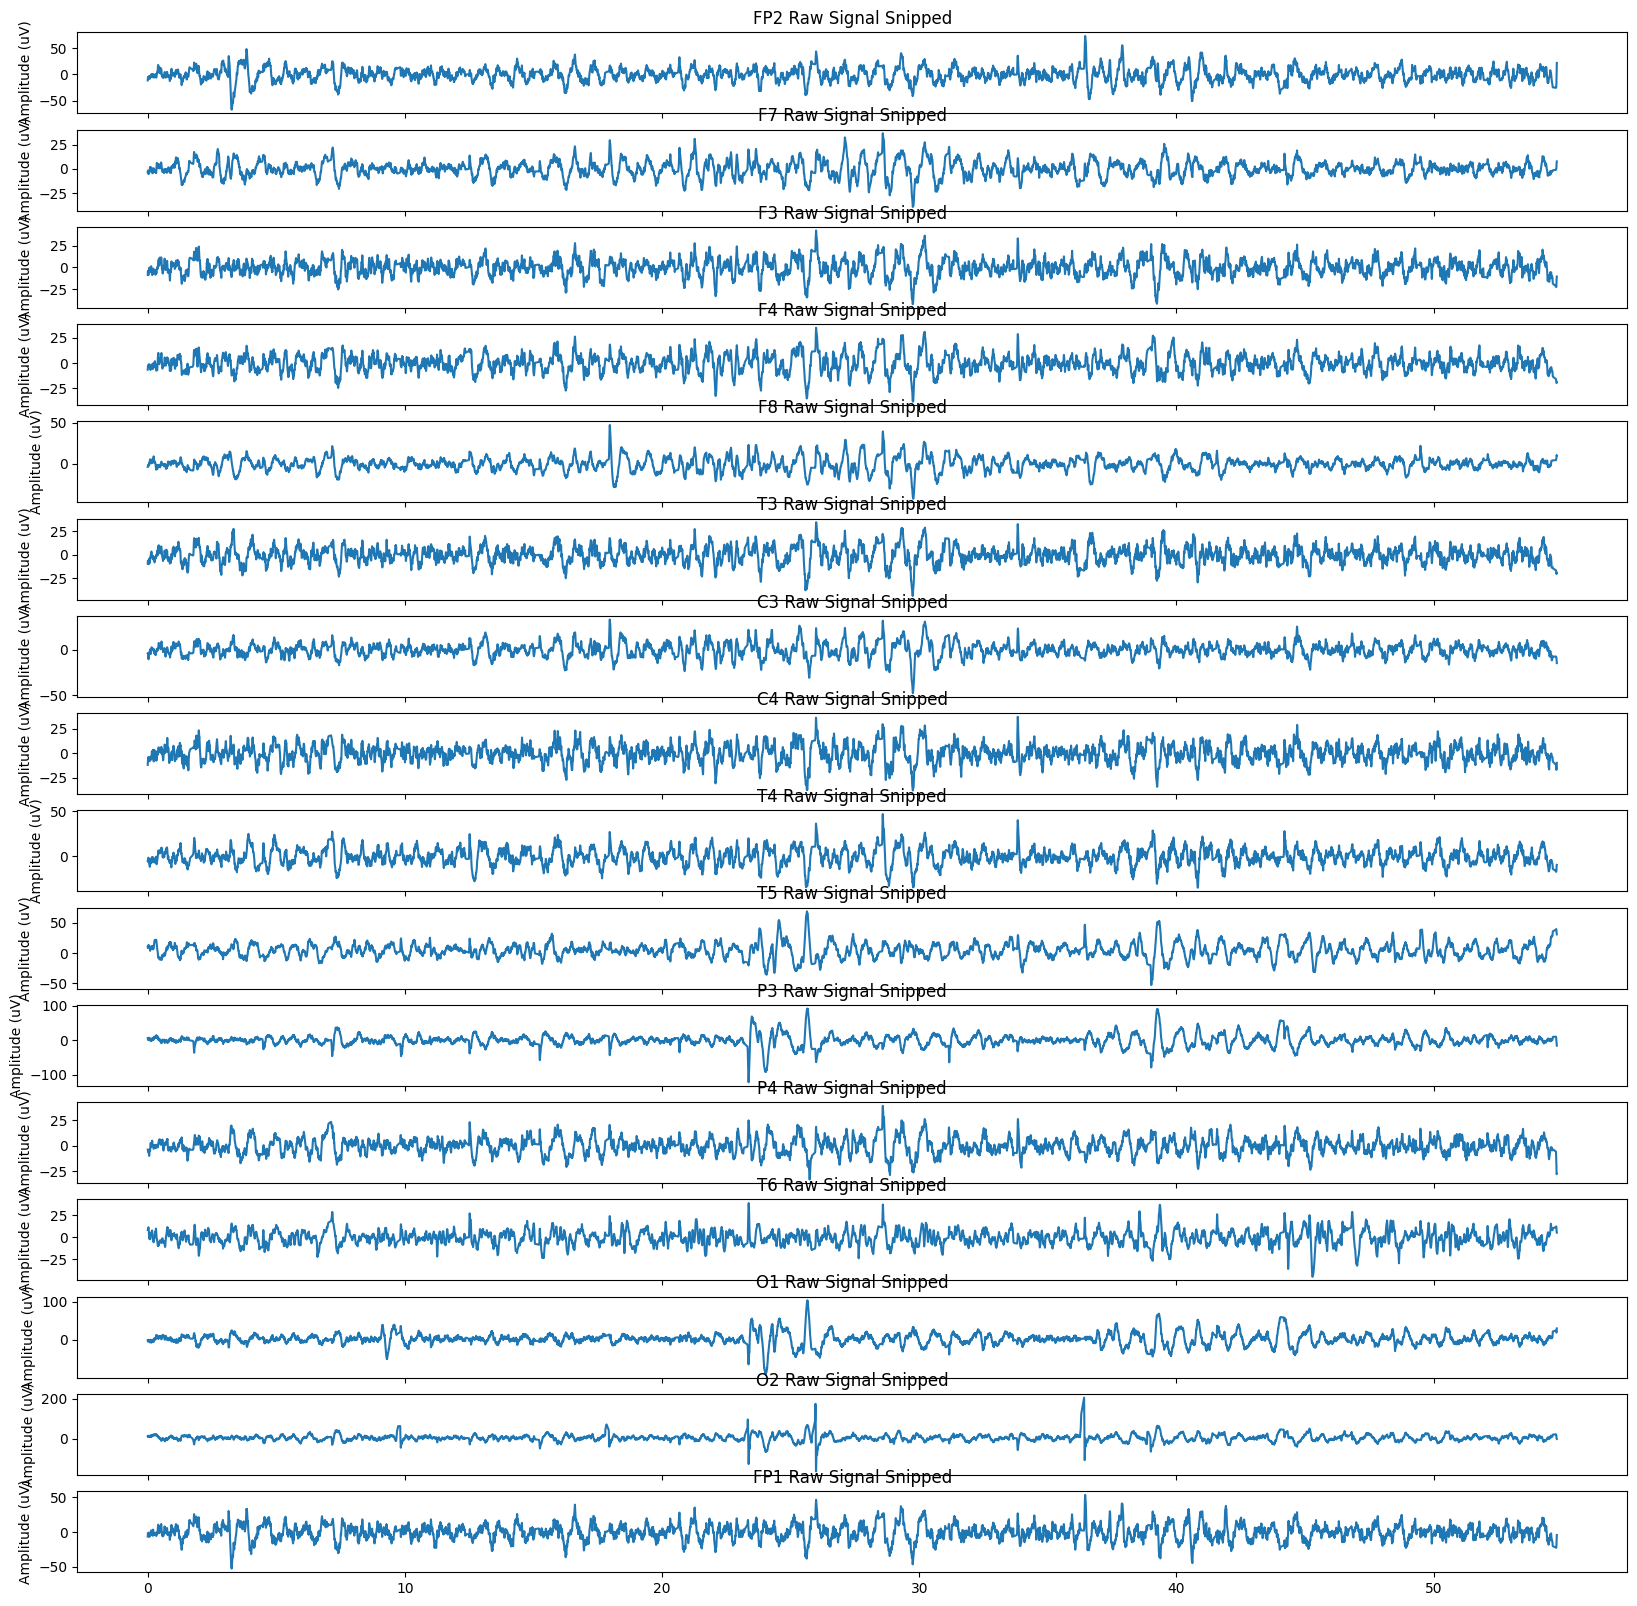

In [ ]:
# after dropping last 10 seconds due to movement
music_df = music_df.iloc[:-10*fs]
fig, axes = plt.subplots(16,1, figsize=(20,20), sharex=True)
for i in range(len(channels)):
    axes[i-1].plot(music_df['timestamp'], music_df[f'{channels[i]}'])
    axes[i-1].set_title(f'{channels[i]} Raw Signal Snipped')
    # axes[i-1].set_xlabel('Timestamp (s)')
    axes[i-1].set_ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

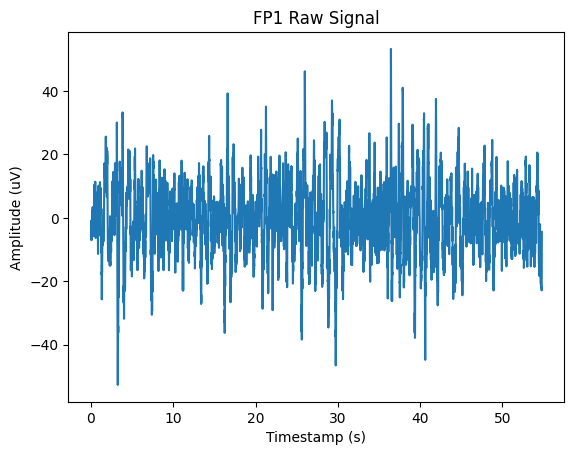

In [ ]:
# individual channel:
plt.plot(music_df['timestamp'], music_df['FP1'])
plt.title('FP1 Raw Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

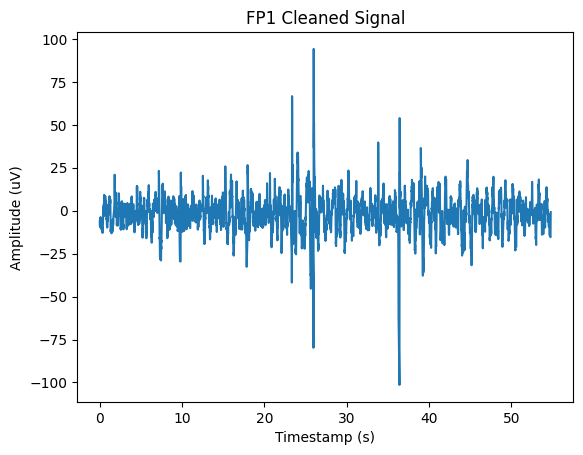

In [ ]:
# now cleaning the eeg data with the butterworth bandpass filter
# print(music_df.iloc[:,1:].values)
# numpy array of shape (17906, 16) where each column is a channel and each row is a time point
cleaned_music_df = butter_bandpass_filter(music_df.iloc[:,1:].values, lowcut, highcut, fs, order=2)
cleaned_music_df_normalized = cleaned_music_df / np.max(np.abs(cleaned_music_df)) * np.max(np.abs(music_df.iloc[:,1:].values))


plt.plot(music_df['timestamp'], cleaned_music_df_normalized[:,15])
plt.title('FP1 Cleaned Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

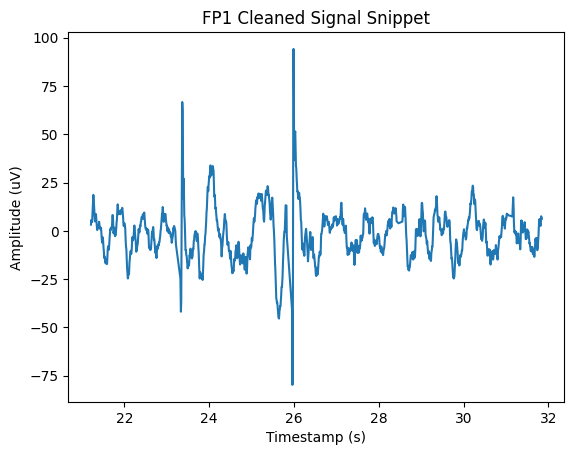

In [ ]:
# get middle of the signal, from 10 to 30 seconds
plt.plot(music_df['timestamp'][10*fs:15*fs], cleaned_music_df_normalized[10*fs:15*fs,15])
plt.title('FP1 Cleaned Signal Snippet')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')